# Example: Specifying demand tariffs using time periods
The example shows how to use time periods to define demand tariffs, and how to use the Optimiser *profile* argument to set a datetime series for the optimiser to use.

### Imports

Here we import everything we need for this example

In [70]:
from datetime import datetime, timedelta, time
import pandas as pd
import numpy as np
np.set_printoptions(suppress=True)

In [71]:
from echo.models.base import Node, OptimisationGraph
from echo.models.agnostic import FlexPort, TellegenNode
from echo.models.electrical import ElectricalDemand, ElectricalStorage, ElectricalGeneration
from echo.configuration import Units
from echo.objectives.tariff import Window, TimePeriod, ResetPeriod, Day, ImportDemandCharge, DemandTariffObjective
from echo.objectives.base import ObjectiveSet
from echo.optimiser import optimise
from echo.models.scenario import EngineSettings, ScenarioSettings

### Defining a profile

The first thing we need to do is define a profile for the optimiser, so that it knows what dates/times the intervals correspond to. Here we simulate a week in Jan 2021, in 15 min intervals

In [72]:
num_days = 7
interval_duration = 15  # minutes
start_date=datetime(2021, 1, 4)
end_date = start_date + timedelta(days=num_days)
expansion_periods = 1  # Number of planning intervals - in echo V1.1, set to 1 always

profile = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date, freq=f'{interval_duration}min', inclusive='left'))

num_time_periods = len(profile)

scenario_settings = ScenarioSettings(
    interval_duration=interval_duration,
    number_of_intervals=num_time_periods,
    number_of_expansion_intervals=expansion_periods,
    discount_rate=0,
)

### Build a basic BTM (Behind The Meter) site

This example creates a simple BTM site with a load, solar and battery attached to the connection point (similar to `manual_examples/btm_battery_example.py`)

First define the load and PV generation data.

In [73]:

test_load = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 2.2, 2.15, 2.02, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 2.05, 2.19]*num_days)

test_pv = 2 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]*num_days)
test_pv *= -1  # convert solar generation to negative to match convention.



Create the nodes (grid, CP, solar, load, battery) and the ports which will connect them.

In [74]:
grid = Node(node_name="grid")
grid.add_port(
    "grid", FlexPort(units=Units.KW)
)

connection_point = TellegenNode(node_name="CP")
connection_point.add_ports_from_list(['load', 'battery', 'pv', 'grid'], FlexPort, units=Units.KW)

load = Node(node_name="load")
l1 = ElectricalDemand()
l1.add_demand_profile_from_array(test_load, expansion_periods)
load.ports['load'] = l1

battery = Node(node_name="battery")
b = ElectricalStorage(max_capacity=15.0,
                       depth_of_discharge_limit=0,
                       charging_power_limit=1.25,
                       discharging_power_limit=-1.25,
                       charging_efficiency=1,
                       discharging_efficiency=1,
                       initial_state_of_charge=0.0)
battery.ports['battery'] = b

solar = Node(node_name="solar")
pv = ElectricalGeneration()
pv.curtailable = False
pv.add_generation_profile_from_array(test_pv, expansion_periods)
solar.ports['pv'] = pv

Create the graph(network) by adding the nodes and joining the nodes via their ports.

In [75]:
network = OptimisationGraph()

network.add_node_obj([grid, battery, load, solar, connection_point])

network.connect_ports_and_create_edge(grid.ports['grid'], connection_point.ports['grid'])
network.connect_ports_and_create_edge(connection_point.ports['load'], load.ports['load'])
network.connect_ports_and_create_edge(connection_point.ports['battery'], battery.ports['battery'])
network.connect_ports_and_create_edge(connection_point.ports['pv'], solar.ports['pv'])

We can visualise our BTM site as a matplotlib figure. The labels are obtained from the `node_name`s. We also add some styling (through the `style` dictionary) to improve the visual appearance.

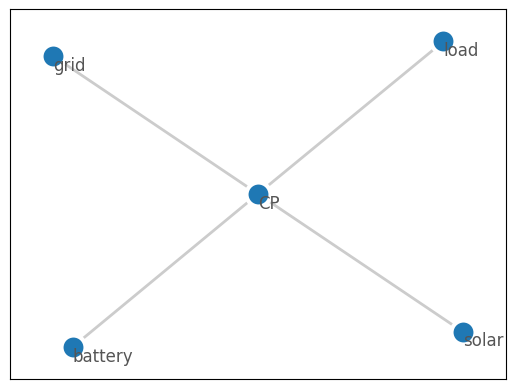

In [76]:
import matplotlib.pyplot as plt

network_figure = plt.figure()
network_axes = network_figure.add_subplot()
style = {
    "edgecolors": "#FFFFFF",  # node border color
    "linewidths": 3,  # node border width
    "edge_color": "#CCCCCC",  # edge color of edges
    "width": 2,  # edge width
    "horizontalalignment": "left",  # label horizontal position
    "verticalalignment": "top",  # label vertical position
    "font_color": "#555555",  # label text color
}
network.draw_on_axes(axes=network_axes, with_labels=True, **style)
plt.show()

### Create a demand tariff
A demand tariff is an object that contains a list of demand charges.
Each demand charge specifies a rate and a window where the demand charge applies.
There is also an option to specify how often the demand charge calculation resets.

Demand charges apply to either imports or exports.


**Step 1**

First we need to define a rate and window for the demand charge
We use the Window class to define the times when the charge applies.
A Window contains a list of time periods, as well as an reset period argument.
The time periods are defined using a start time, end time, and day type (list)

In [82]:
peak_rate = 2.0  # the rate is applied per kW

peak_window = Window(
    time_periods=[
        TimePeriod(start_time=time(7,0), end_time=time(9,0), day_type=[Day.weekday, Day.weekday]),
        TimePeriod(start_time=time(18, 0),end_time=time(21, 0),day_type=[Day.weekday, Day.weekend])
    ],
    reset_periods=ResetPeriod.day   # use the ResetPeriod class to define the reset period.
)

**Step 2**

Now we can define the demand charge using the `ImportDemandCharge` class.

Since we want the charge to apply to *imports* only we need to use `ImportDemandCharge` rather than the more general `DemandCharge` (which applies to both imports and exports)

When defining a demand charge using a Window object, we need to use `.to_bool_periods()` and `.get_reset_period_array()` to convert the window to a boolean array, and to convert the reset periods to a list of time intervals.

In [78]:
peak_charge = ImportDemandCharge(rate=peak_rate,
                                 window_array=peak_window.to_bool_periods(profile),  # Need to convert the window to bool periods
                                 min_demand=0.0,
                                 reset_periods=peak_window.get_reset_period_array(profile))  # need to convert the reset period to an array

demand_tariff = DemandTariffObjective(component=connection_point.ports['grid'],
                                      demand_charges=[peak_charge])

objective_set = ObjectiveSet(objective_list=[demand_tariff])

### Setup and run the optimiser

Here we are going to use [cplex](https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer) solver.

In [79]:
engine_settings = EngineSettings(
    engine="cplex",
    engine_executable="",
    bigM=5000000,  # This value has been arbitrarily chosen
    smallM=0.0001,  # This value has been arbitrarily chosen
)

Perform the optimisation passing in all the required information

In [80]:
optimise_results = optimise(
    scenario_settings=scenario_settings,
    engine_settings=engine_settings,
    graph=network,
    objective_set=objective_set,
    profile=profile
)


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmpwjsedro5.cplex.log' open.
CPLEX> Problem '/tmp/tmpp2af0rr2.pyomo.lp' read.
Read time = 0.02 sec. (0.84 ticks)
CPLEX> Problem name         : /tmp/tmpp2af0rr2.pyomo.lp
Objective sense      : Minimize
Variables            :    6727  [Nneg: 679,  Box: 1344,  Free: 3360,
                                 Binary: 672,  Other: 672]
Objective nonzeros   :       7
Linear constraints   :   10752  [Less: 6048,  Equal: 4704]
  Nonzeros           :   18267
  RHS nonzeros       :    1722

Variables            : Min LB: -1.250000        Max UB: 15.00000       
Objective nonzeros   : Min   : 2.000000  

### Looking at the results
We can check the peak demand value by looking at the `.max_demand_val` attribute of the demand charge object.
This will return a list of values, one for each period where the calculation is made. Because we are simulating a week, and resetting our calculation every day, we will have 7 values.

In [81]:
print(optimise_results.values(peak_charge.max_demand_val))

[1.88 1.88 1.88 1.88 1.88 1.88 1.88]
